In [1]:
#Load A Dataset
import pandas as pd

df=pd.read_csv("mock_kaggle.csv")
print(df.head())
print(df.info())
print(df.tail())
print(df.describe())

         data  Sale  Stock  Price
0  2014-01-01     0   4972   1.29
1  2014-01-01     4   6853   1.29
2  2014-01-02    70   4902   1.29
3  2014-01-03    59   4843   1.29
4  2014-01-04    93   4750   1.29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   data    938 non-null    object 
 1   Sale    938 non-null    int64  
 2   Stock   938 non-null    int64  
 3   Price   938 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 29.4+ KB
None
           data  Sale  Stock  Price
933  2016-07-27    98   3179   2.39
934  2016-07-28   108   3071   2.39
935  2016-07-29   128   4095   2.39
936  2016-07-30   270   3825   2.39
937  2016-07-31   183   3642   2.39
             Sale        Stock       Price
count  938.000000   938.000000  938.000000
mean    90.441365  1613.849680    1.592249
std     80.688508  1366.738446    0.529311
min      0.000

In [2]:
# print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print(df)
# df = df.dropna()

Duplicates: 0
           data  Sale  Stock  Price
0    2014-01-01     0   4972   1.29
1    2014-01-01     4   6853   1.29
2    2014-01-02    70   4902   1.29
3    2014-01-03    59   4843   1.29
4    2014-01-04    93   4750   1.29
..          ...   ...    ...    ...
933  2016-07-27    98   3179   2.39
934  2016-07-28   108   3071   2.39
935  2016-07-29   128   4095   2.39
936  2016-07-30   270   3825   2.39
937  2016-07-31   183   3642   2.39

[938 rows x 4 columns]


In [3]:
#Data conversion
df["data"]=pd.to_datetime(df["data"])
print(df["data"])

0     2014-01-01
1     2014-01-01
2     2014-01-02
3     2014-01-03
4     2014-01-04
         ...    
933   2016-07-27
934   2016-07-28
935   2016-07-29
936   2016-07-30
937   2016-07-31
Name: data, Length: 938, dtype: datetime64[ns]


In [4]:
#sort the date
df=df.sort_values("data")
print(df)

          data  Sale  Stock  Price
0   2014-01-01     0   4972   1.29
1   2014-01-01     4   6853   1.29
2   2014-01-02    70   4902   1.29
3   2014-01-03    59   4843   1.29
4   2014-01-04    93   4750   1.29
..         ...   ...    ...    ...
933 2016-07-27    98   3179   2.39
934 2016-07-28   108   3071   2.39
935 2016-07-29   128   4095   2.39
936 2016-07-30   270   3825   2.39
937 2016-07-31   183   3642   2.39

[938 rows x 4 columns]


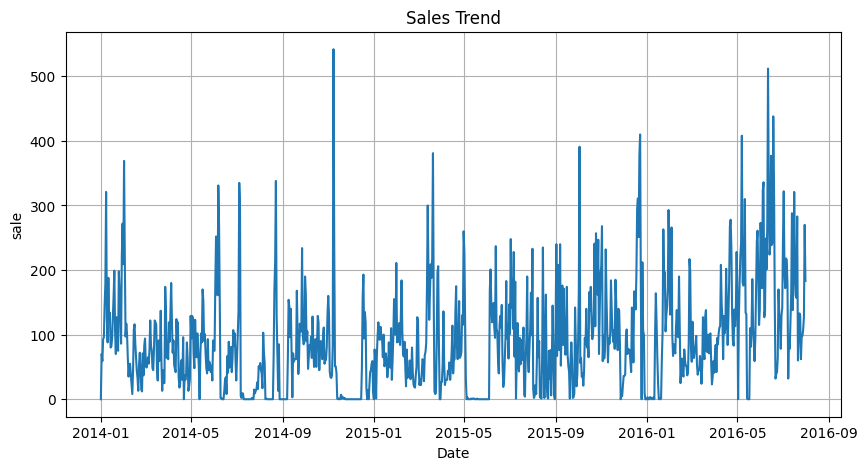

In [5]:
#visual
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["data"],df["Sale"])
plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("sale")
plt.grid(True)
plt.show()

In [6]:
#resample
month=df.resample("ME", on="data")["Sale"].sum()
print(month)

data
2014-01-31    3989
2014-02-28    2018
2014-03-31    2137
2014-04-30    1990
2014-05-31    2493
2014-06-30    2629
2014-07-31    1131
2014-08-31    1452
2014-09-30    2185
2014-10-31    2765
2014-11-30    1462
2014-12-31    1010
2015-01-31    2465
2015-02-28    1918
2015-03-31    3379
2015-04-30    2123
2015-05-31     647
2015-06-30    2880
2015-07-31    3104
2015-08-31    1826
2015-09-30    2790
2015-10-31    3974
2015-11-30    3214
2015-12-31    3914
2016-01-31    2365
2016-02-29    2832
2016-03-31    2206
2016-04-30    4028
2016-05-31    4407
2016-06-30    6347
2016-07-31    5154
Freq: ME, Name: Sale, dtype: int64


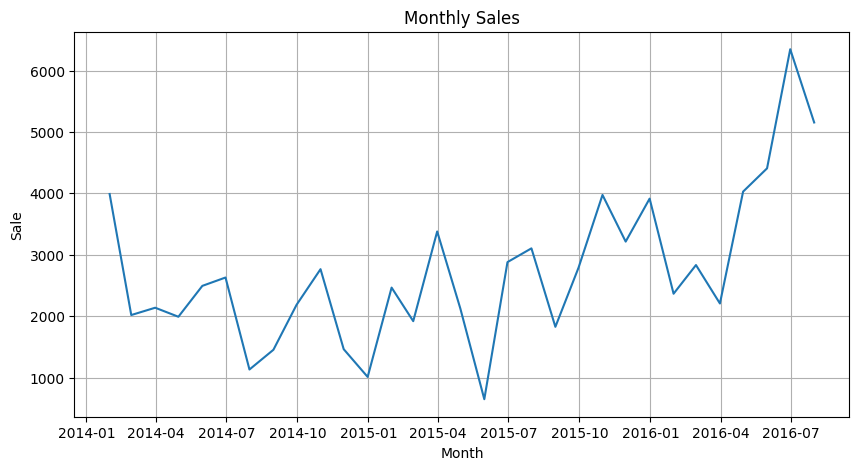

In [7]:
#month data visual
plt.figure(figsize=(10,5))
plt.plot(month)
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sale")
plt.grid(True)
plt.show()

data
2014-01-31            NaN
2014-02-28            NaN
2014-03-31    2714.666667
2014-04-30    2048.333333
2014-05-31    2206.666667
2014-06-30    2370.666667
2014-07-31    2084.333333
2014-08-31    1737.333333
2014-09-30    1589.333333
2014-10-31    2134.000000
2014-11-30    2137.333333
2014-12-31    1745.666667
2015-01-31    1645.666667
2015-02-28    1797.666667
2015-03-31    2587.333333
2015-04-30    2473.333333
2015-05-31    2049.666667
2015-06-30    1883.333333
2015-07-31    2210.333333
2015-08-31    2603.333333
2015-09-30    2573.333333
2015-10-31    2863.333333
2015-11-30    3326.000000
2015-12-31    3700.666667
2016-01-31    3164.333333
2016-02-29    3037.000000
2016-03-31    2467.666667
2016-04-30    3022.000000
2016-05-31    3547.000000
2016-06-30    4927.333333
2016-07-31    5302.666667
Freq: ME, Name: Sale, dtype: float64


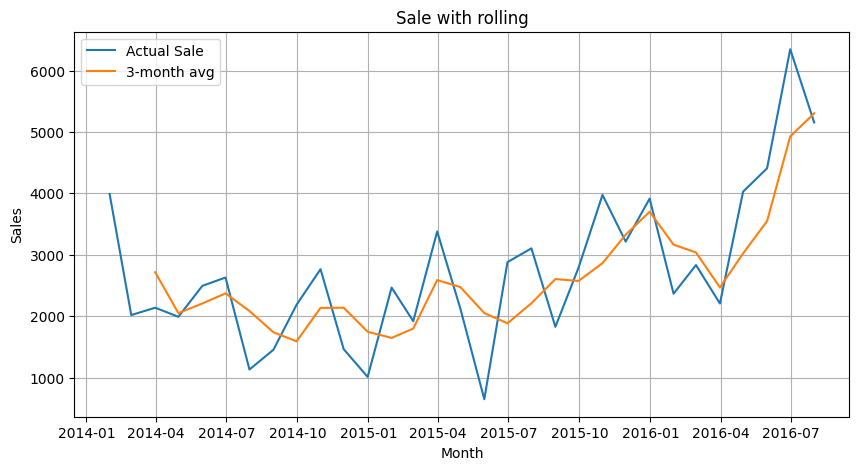

In [8]:
#rolling mean
rolling=month.rolling(window=3).mean()
print(rolling)
plt.figure(figsize=(10,5))
plt.plot(month,label="Actual Sale")
plt.plot(rolling,label="3-month avg")
plt.title("Sale with rolling")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [10]:
from statsmodels.tsa.stattools import adfuller

res=adfuller(month)
print("ADF STAT: ",res[0])
print("p-value: ",res[1])

if res[1]<0.05:
 print("Stationary")
else:
 print("Non-stationary")

ModuleNotFoundError: No module named 'statsmodels.tsa.stattools'

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model=SARIMAX(month,order=(1,1,1),seasonal_order=(1,1,1,12))
model_fit=model.fit()
forecast=model_fit.forecast(steps=3)
print("Forecast : ",forecast)

a:\MLWORKOUT\env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
a:\MLWORKOUT\env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Forecast :  2016-08-31    3895.694570
2016-09-30    4205.663894
2016-10-31    4760.796705
Freq: ME, Name: predicted_mean, dtype: float64


a:\MLWORKOUT\env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


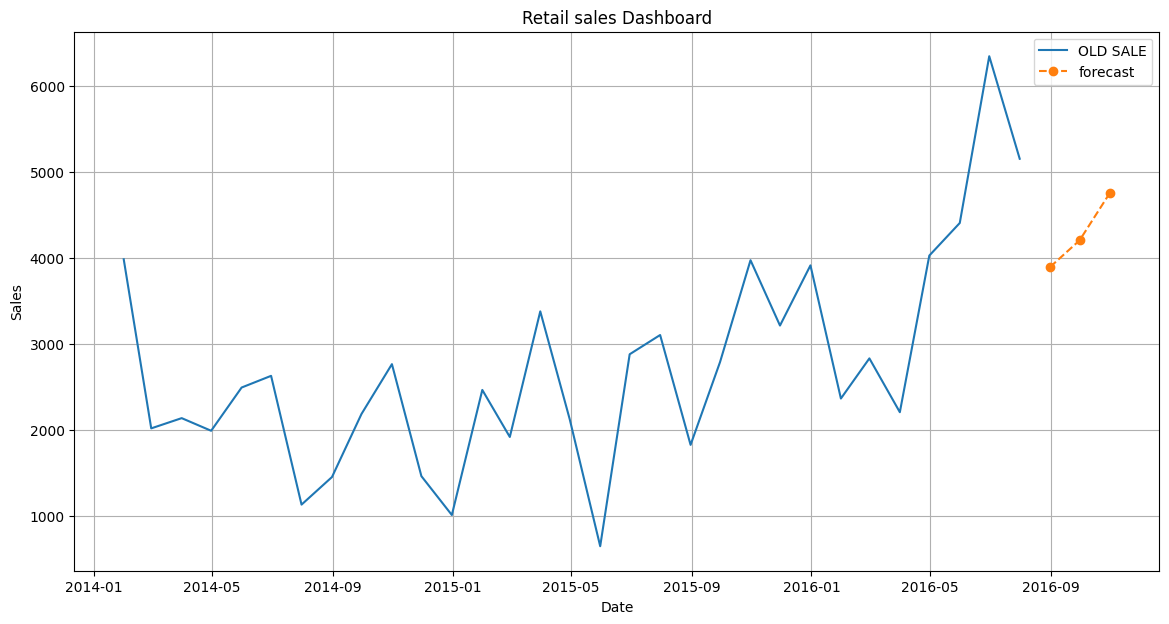

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(month.index,month,label="OLD SALE")
plt.plot(forecast,marker="o",
         linestyle="--",label="forecast")
plt.title("Retail sales Dashboard")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

data={
 "gender":["male","female","male","female"],
 "Hours":[5,6,3,2],
 "result":[1,1,0,0]
}
df=pd.DataFrame(data)

a=LabelEncoder()
df["gender"]=a.fit_transform(df["gender"])

x=df[["gender","Hours"]]
y=df["result"]

model=LogisticRegression()

model.fit(x,y)

new=[[1,8]]

pred=model.predict(new)
print(pred)


[1]


a:\MLWORKOUT\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd 

data={
 "age":[1,2,3,5,6],
 "marks":[None,None,9,9,36]
}
df=pd.DataFrame(data)
print(df)
print(df.isnull().sum())

   age  marks
0    1    NaN
1    2    NaN
2    3    9.0
3    5    9.0
4    6   36.0
age      0
marks    2
dtype: int64
